PDF saved: C:\Users\benel\OneDrive\Desktop\Python\Thesis_xyz\results\plots\all_models\cumulative_return_log.pdf


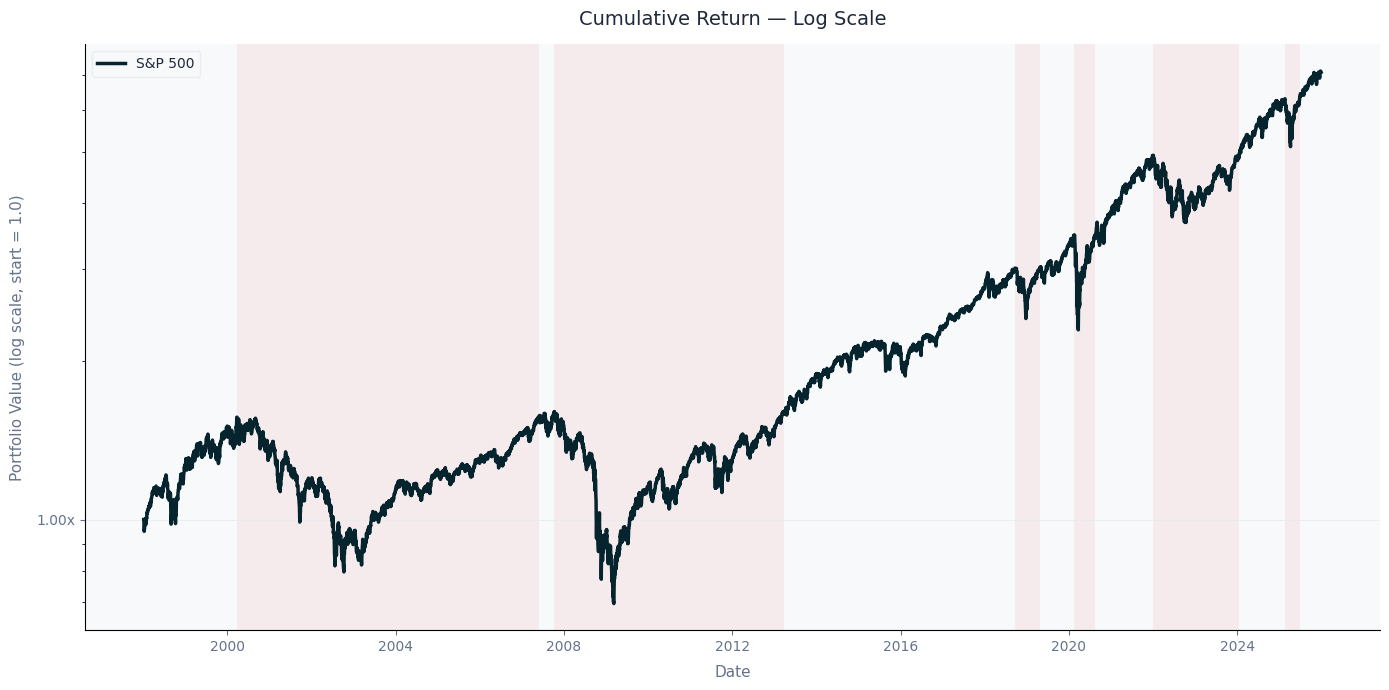

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.graph_objects as go
from pathlib import Path

_DATA_PATH = Path(r"C:/Users/benel/OneDrive/Desktop/Python/Thesis_xyz")
_DATA_DIR  = _DATA_PATH / "results" / "data"
_OUT_DIR   = _DATA_PATH / "results" / "plots" / "all_models"
_OUT_DIR.mkdir(parents=True, exist_ok=True)
_START, _END = "1998-01-01", "2025-12-31"

CRISIS_PERIODS = [
    ("Dotcom Crash",       "2000-03-23", "2007-05-31"),
    ("GFC",                "2007-10-09", "2013-03-28"),
    ("Monetary Policy",    "2018-09-21", "2019-04-23"),
    ("COVID-19",           "2020-02-19", "2020-08-12"),
    ("Russia/Ukraine",     "2022-01-03", "2024-01-19"),
    ("Trade Policy Shock", "2025-02-19", "2025-06-26"),
]
BG, PANEL, GRID = "#FFFFFF", "#F8F9FA", "#E9ECEF"
TEXT, SUBTEXT   = "#1E293B", "#64748B"

def _avg_runs(model_dir, pattern):
    dfs, run = [], 1
    while True:
        p = model_dir / pattern.format(run=run)
        if not p.exists(): break
        df = pd.read_csv(p, index_col="date", parse_dates=True).sort_index()
        df = df.loc[_START:_END].dropna(subset=["log_return"])
        dfs.append(df["log_return"])
        run += 1
    if not dfs: return None, 0
    avg = pd.concat(dfs, axis=1).mean(axis=1).dropna()
    return pd.DataFrame({"log_return": avg, "cumulative_value": np.exp(avg.cumsum())}), len(dfs)

def _single(path, log_col="log_return"):
    if not path.exists(): return None
    df = pd.read_csv(path, index_col="date", parse_dates=True).sort_index()
    df = df.loc[_START:_END].dropna(subset=[log_col])
    if log_col != "log_return":
        df = df.rename(columns={log_col: "log_return"})
    df["cumulative_value"] = np.exp(df["log_return"].cumsum())
    return df

lstm_df, lstm_n = _avg_runs(_DATA_DIR / "lstm",    "portfolio_lstm_Quarterly_{run}.csv")
xgb_df,  xgb_n  = _avg_runs(_DATA_DIR / "xgboost", "portfolio_xgb_Quarterly_{run}.csv")
ew_df           = _single(_DATA_DIR / "equal_weight" / "portfolio_Quarterly.csv")
hrp_df          = _single(_DATA_DIR / "hrp"          / "portfolio_Quarterly.csv")
bench_df        = _single(_DATA_DIR / "benchmark"    / "portfolio.csv", log_col="log_returns_per_day")

# (cumulative_value, hex_color, linewidth)
series = {}
if bench_df is not None: series["S&P 500"]         = (bench_df["cumulative_value"], "#05242E", 2.5)
if ew_df    is not None: series["1/N"]                 = (ew_df["cumulative_value"],    "#CAC9CE", 1.8)
if hrp_df   is not None: series["HRP"]                          = (hrp_df["cumulative_value"],   "#36A7AF", 1.8)
if xgb_df   is not None: series["XGBoost"] = (xgb_df["cumulative_value"],   "#20B42C", 1.8)
if lstm_df  is not None: series["LSTM"]    = (lstm_df["cumulative_value"],  "#EB2C2C", 1.8)

TITLE = "Cumulative Return — Log Scale"

# ── 1) Interactive Plotly chart ───────────────────────────────────────────────
fig = go.Figure()
if series:
    first_idx = next(iter(series.values()))[0].index
    for cname, c_start, c_end in CRISIS_PERIODS:
        s = first_idx[first_idx >= pd.Timestamp(c_start)]
        e = first_idx[first_idx <= pd.Timestamp(c_end)]
        if s.empty or e.empty: continue
        fig.add_vrect(x0=s[0], x1=e[-1], fillcolor="rgba(220,38,38,0.08)", layer="below", line_width=0)
        

for label, (cum_series, color, _lw) in series.items():
    ls = 'dash' if label in ["S&P 500"] else 'solid'
    fig.add_trace(go.Scatter(
        x=cum_series.index, y=cum_series.values, mode="lines", name=label,
        line=dict(color=color, width=2, dash=ls), # Added dash here
        hovertemplate="%{x|%b %d, %Y}<br>" + label + ": %{y:.3f}x<extra></extra>",
    ))

fig.update_layout(
    title=dict(text=TITLE, font=dict(size=18, color=TEXT, family="Inter, Arial"), x=0.5, xanchor="center"),
    height=580, paper_bgcolor=BG, plot_bgcolor=PANEL,
    font=dict(family="Inter, Arial, sans-serif", size=12, color=TEXT),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1, font=dict(color=TEXT, size=11)),
    margin=dict(l=80, r=50, t=100, b=50),
    hoverlabel=dict(bgcolor="white", font_size=12, font_color=TEXT, bordercolor=GRID),
)
fig.update_xaxes(showgrid=False, tickfont=dict(color=SUBTEXT), linecolor=GRID)
fig.update_yaxes(type="log", tickformat=".2f", ticksuffix="x", gridcolor=GRID,
                 tickfont=dict(color=SUBTEXT), title_text="Portfolio Value (log scale, start = 1.0)",
                 title_font=dict(color=SUBTEXT), linecolor=GRID)
#fig.show()

# ── 2) PDF export via matplotlib (vector quality) ─────────────────────────────
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.facecolor":    "#F8F9FA",
    "figure.facecolor":  "white",
    "grid.color":        "#E9ECEF",
    "grid.linewidth":    0.6,
})

fig_pdf, ax = plt.subplots(figsize=(14, 7))

for cname, c_start, c_end in CRISIS_PERIODS:
    ax.axvspan(pd.Timestamp(c_start), pd.Timestamp(c_end),
               alpha=0.08, color="#DB5353", zorder=0, linewidth=0)

for label, (cum_series, color, lw) in series.items():
    ax.plot(cum_series.index, cum_series.values, color=color, linewidth=lw, label=label, zorder=3)

ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.2f}x"))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())
ax.set_xlabel("Date", fontsize=11, color="#64748B", labelpad=8)
ax.set_ylabel("Portfolio Value (log scale, start = 1.0)", fontsize=11, color="#64748B", labelpad=8)
ax.set_title(TITLE, fontsize=14, color="#1E293B", pad=14)
ax.tick_params(colors="#64748B", labelsize=10)
ax.grid(True, which="major", axis="y", zorder=0)
ax.grid(False, axis="x")

y_top = ax.get_ylim()[1]


leg = ax.legend(loc="upper left", fontsize=10, framealpha=0.9, edgecolor="#E9ECEF", ncol=2)
for txt in leg.get_texts():
    txt.set_color("#1E293B")

fig_pdf.tight_layout()
pdf_path = _OUT_DIR / "cumulative_return_log.pdf"
fig_pdf.savefig(pdf_path, format="pdf", bbox_inches="tight")
print(f"PDF saved: {pdf_path}")
#plt.show()

In [ ]:

# All 9 crisis periods with trough — matching metrics.py CRISIS_PERIODS
CRISIS_PERIODS_9 = [
    ('Dotcom Crash',                    '2000-03-23', '2002-10-09', '2007-05-31'),
    ('GFC (Full)',                      '2007-10-09', '2009-03-09', '2013-03-28'),
    ('Early Credit Crunch',             '2007-10-09', '2008-09-15', '2008-09-15'),
    ('Acute GFC Crash',                 '2008-09-15', '2009-03-09', '2010-04-23'),
    ('European Debt + US Debt Ceiling', '2010-04-23', '2011-10-03', '2012-02-23'),
    ('Monetary Policy',                 '2018-09-21', '2018-12-24', '2019-04-23'),
    ('COVID-19',                        '2020-02-19', '2020-03-23', '2020-08-12'),
    ('Russia/Ukraine',                  '2022-01-03', '2022-10-12', '2024-01-19'),
    ('Trade Policy Shock',              '2025-02-19', '2025-04-08', '2025-06-26'),
]

if bench_df is not None:
    cv = bench_df['cumulative_value']
    idx = cv.index

    def nearest(date_str, side='fwd'):
        ts = pd.Timestamp(date_str)
        candidates = idx[idx >= ts] if side == 'fwd' else idx[idx <= ts]
        return candidates[0] if side == 'fwd' and not candidates.empty else \
               candidates[-1] if side == 'bwd' and not candidates.empty else None

    hdr = f"{'Crisis':<35} {'Start':<12} {'Val':>8}   {'Trough':<12} {'Val':>8}   {'End':<12} {'Val':>8}"
    print(hdr)
    print("-" * len(hdr))
    for cname, c_start, c_trough, c_end in CRISIS_PERIODS_9:
        s = nearest(c_start,  'fwd')
        t = nearest(c_trough, 'fwd')
        e = nearest(c_end,    'bwd')
        sv = f"{cv[s]:.4f}" if s is not None else "N/A"
        tv = f"{cv[t]:.4f}" if t is not None else "N/A"
        ev = f"{cv[e]:.4f}" if e is not None else "N/A"
        sd = str(s.date()) if s is not None else "N/A"
        td = str(t.date()) if t is not None else "N/A"
        ed = str(e.date()) if e is not None else "N/A"
        print(f"{cname:<35} {sd:<12} {sv:>8}   {td:<12} {tv:>8}   {ed:<12} {ev:>8}")


Crisis                              Start             Val   Trough            Val   End               Val
---------------------------------------------------------------------------------------------------------
Dotcom Crash                        2000-03-23     1.5664   2002-10-09     0.7966   2007-05-31     1.5698
GFC (Full)                          2007-10-09     1.6052   2009-03-09     0.6938   2013-03-28     1.6094
Early Credit Crunch                 2007-10-09     1.6052   2008-09-15     1.2232   2010-04-23     1.2484
Acute GFC Crash                     2008-09-15     1.2232   2009-03-09     0.6938   2010-04-23     1.2484
European Debt + US Debt Ceiling     2010-04-23     1.2484   2011-10-03     1.1274   2012-03-23     1.4329
Monetary Policy                     2018-09-21     3.0047   2018-12-24     2.4113   2019-04-23     3.0088
COVID-19                            2020-02-19     3.4728   2020-03-23     2.2947   2020-08-12     3.4669
Russia/Ukraine                      2022-01-03